# Phase 1 延伸 — Lag-2 / Lag-3 Transition 分析

**前情**：Lag-1 一區 Test B 0/38 顯著，Test A 0/1,444 顯著；二區同樣全無訊號。

**本 notebook 問題**：延後 2 期或 3 期的跨期關聯是否存在？

| Lag | 含義 | 樣本數 |
|-----|------|--------|
| 2   | T[x][y] = 第 t 期含 x 且第 t+2 期含 y | N−2 = 1,805 |
| 3   | T[x][y] = 第 t 期含 x 且第 t+3 期含 y | N−3 = 1,804 |

**注意**：每個 lag 的 FDR 獨立校正；三個 lag 合併看時，注意家族誤差率（多重 lag 搜尋）。

## 1. 載入資料 & 工具函式

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Microsoft JhengHei",
    "axes.unicode_minus": False,
})

conn = sqlite3.connect(Path("lottery.db"))
df = pd.read_sql(
    "SELECT n1,n2,n3,n4,n5,n6,n_zone2 FROM draws WHERE split='train' ORDER BY id",
    conn,
)
conn.close()

Z1 = ["n1","n2","n3","n4","n5","n6"]
draws_z1 = [set(row) for row in df[Z1].itertuples(index=False, name=None)]
draws_z2  = list(df["n_zone2"])
N = len(df)
print(f"訓練期數：{N}")

訓練期數：1807


In [2]:
def build_transition_z1(lag: int) -> tuple[np.ndarray, np.ndarray]:
    """回傳 (T, freq_src)：T[x,y]=計數，freq_src[x]=x 作為來源的次數。"""
    T = np.zeros((39, 39), dtype=int)
    freq_src = np.zeros(39, dtype=int)
    for t in range(N - lag):
        for x in draws_z1[t]:
            freq_src[x] += 1
            for y in draws_z1[t + lag]:
                T[x, y] += 1
    return T, freq_src


def build_transition_z2(lag: int) -> tuple[np.ndarray, np.ndarray]:
    T = np.zeros((9, 9), dtype=int)
    freq_src = np.zeros(9, dtype=int)
    for t in range(N - lag):
        x = draws_z2[t]
        freq_src[x] += 1
        T[x, draws_z2[t + lag]] += 1
    return T, freq_src


def run_tests(T: np.ndarray, freq_src: np.ndarray,
              n_nums: int, p0: float) -> dict:
    """
    n_nums: 38（一區）或 8（二區）
    p0    : 6/38 or 1/8
    回傳含 testB_df、testA_df、sig_B_fdr、sig_A 的 dict。
    """
    nums = range(1, n_nums + 1)

    # Test B
    B_rows = []
    for x in nums:
        row = T[x, 1:n_nums+1]
        total = row.sum()
        if total == 0:
            continue
        chi2, p = stats.chisquare(row, f_exp=np.full(n_nums, total / n_nums))
        B_rows.append({"x": x, "chi2": chi2, "p": p})
    testB_df = pd.DataFrame(B_rows).set_index("x")
    _, q_B, _, _ = multipletests(testB_df["p"].values, method="fdr_bh")
    testB_df["q_bh"] = q_B
    sig_B_raw = testB_df[testB_df["p"] < 0.05]
    sig_B_fdr = testB_df[testB_df["q_bh"] < 0.05]

    # Test A
    A_rows = []
    for x in nums:
        n_x = freq_src[x]
        if n_x == 0:
            continue
        for y in nums:
            k = T[x, y]
            p_val = stats.binomtest(k, n=n_x, p=p0, alternative="two-sided").pvalue
            A_rows.append({"x": x, "y": y, "k": k, "n": n_x,
                           "obs_rate": k / n_x, "p_raw": p_val})
    testA_df = pd.DataFrame(A_rows)
    _, q_A, _, _ = multipletests(testA_df["p_raw"].values, method="fdr_bh")
    testA_df["q_bh"] = q_A
    testA_df["lift"] = testA_df["obs_rate"] / p0
    sig_A = testA_df[testA_df["q_bh"] < 0.05]

    return {
        "testB_df": testB_df, "testA_df": testA_df,
        "sig_B_raw": sig_B_raw, "sig_B_fdr": sig_B_fdr, "sig_A": sig_A,
    }

print("工具函式定義完成")

工具函式定義完成


## 2. 跑 Lag-2 & Lag-3（一區 + 二區）

In [3]:
results = {}   # lag -> {z1: ..., z2: ...}

for lag in [2, 3]:
    print(f"=== Lag-{lag} ===")

    T_z1, freq_z1 = build_transition_z1(lag)
    r_z1 = run_tests(T_z1, freq_z1, n_nums=38, p0=6/38)

    T_z2, freq_z2 = build_transition_z2(lag)
    r_z2 = run_tests(T_z2, freq_z2, n_nums=8,  p0=1/8)

    results[lag] = {"z1": r_z1, "z2": r_z2,
                    "T_z1": T_z1, "T_z2": T_z2,
                    "freq_z1": freq_z1, "freq_z2": freq_z2}

    n_pairs = N - lag
    print(f"  一區 Test B 原始p<0.05：{len(r_z1['sig_B_raw'])}/38 "
          f"| FDR q<0.05：{len(r_z1['sig_B_fdr'])}/38")
    print(f"  一區 Test A FDR q<0.05：{len(r_z1['sig_A'])}/{len(r_z1['testA_df'])}")
    print(f"  二區 Test B 原始p<0.05：{len(r_z2['sig_B_raw'])}/8 "
          f"| FDR q<0.05：{len(r_z2['sig_B_fdr'])}/8")
    print(f"  二區 Test A FDR q<0.05：{len(r_z2['sig_A'])}/{len(r_z2['testA_df'])}")
    print()

=== Lag-2 ===


  一區 Test B 原始p<0.05：0/38 | FDR q<0.05：0/38
  一區 Test A FDR q<0.05：0/1444
  二區 Test B 原始p<0.05：0/8 | FDR q<0.05：0/8
  二區 Test A FDR q<0.05：0/64

=== Lag-3 ===


  一區 Test B 原始p<0.05：0/38 | FDR q<0.05：0/38
  一區 Test A FDR q<0.05：0/1444
  二區 Test B 原始p<0.05：0/8 | FDR q<0.05：0/8
  二區 Test A FDR q<0.05：0/64



## 3. 視覺化 — Lag-1 / 2 / 3 p-value 比較

C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_14240\1035618741.py:37: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_14240\1035618741.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()


C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


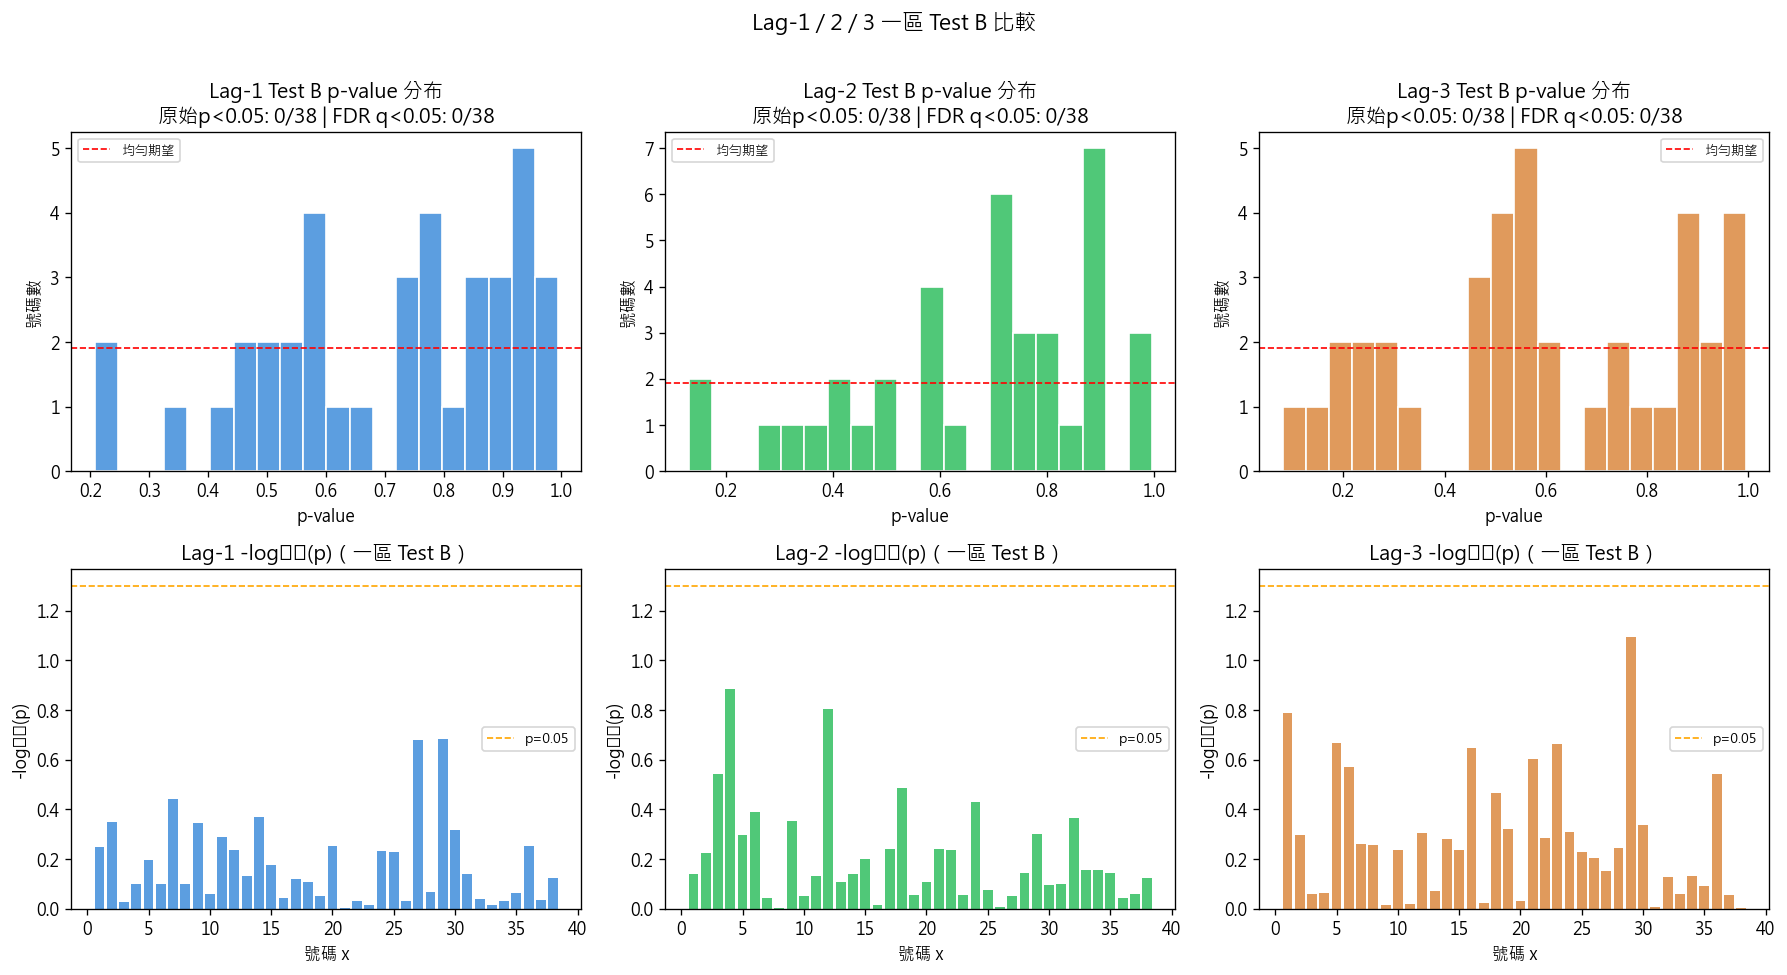

In [4]:
# 重跑 lag-1 以便並列比較
T_z1_lag1, freq_z1_lag1 = build_transition_z1(1)
r_z1_lag1 = run_tests(T_z1_lag1, freq_z1_lag1, n_nums=38, p0=6/38)
all_lag_z1 = {1: r_z1_lag1, 2: results[2]["z1"], 3: results[3]["z1"]}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = {1: "#5c9ee0", 2: "#50c878", 3: "#e09a5c"}

for col, lag in enumerate([1, 2, 3]):
    r = all_lag_z1[lag]
    pvals = r["testB_df"]["p"].values

    # 上排：p-value 直方圖（Test B）
    ax = axes[0, col]
    ax.hist(pvals, bins=20, color=colors[lag], edgecolor="white")
    ax.axhline(len(pvals) / 20, color="red", linestyle="--", linewidth=1,
               label="均勻期望")
    n_sig_raw = len(r["sig_B_raw"])
    n_sig_fdr = len(r["sig_B_fdr"])
    ax.set_title(f"Lag-{lag} Test B p-value 分布\n"
                 f"原始p<0.05: {n_sig_raw}/38 | FDR q<0.05: {n_sig_fdr}/38")
    ax.set_xlabel("p-value")
    ax.set_ylabel("號碼數")
    ax.legend(fontsize=8)

    # 下排：-log10(p) 條形圖
    ax = axes[1, col]
    ax.bar(r["testB_df"].index, -np.log10(pvals), color=colors[lag])
    ax.axhline(-np.log10(0.05), color="orange", linestyle="--",
               linewidth=1, label="p=0.05")
    ax.set_title(f"Lag-{lag} -log₁₀(p)（一區 Test B）")
    ax.set_xlabel("號碼 x")
    ax.set_ylabel("-log₁₀(p)")
    ax.legend(fontsize=8)

plt.suptitle("Lag-1 / 2 / 3 一區 Test B 比較", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

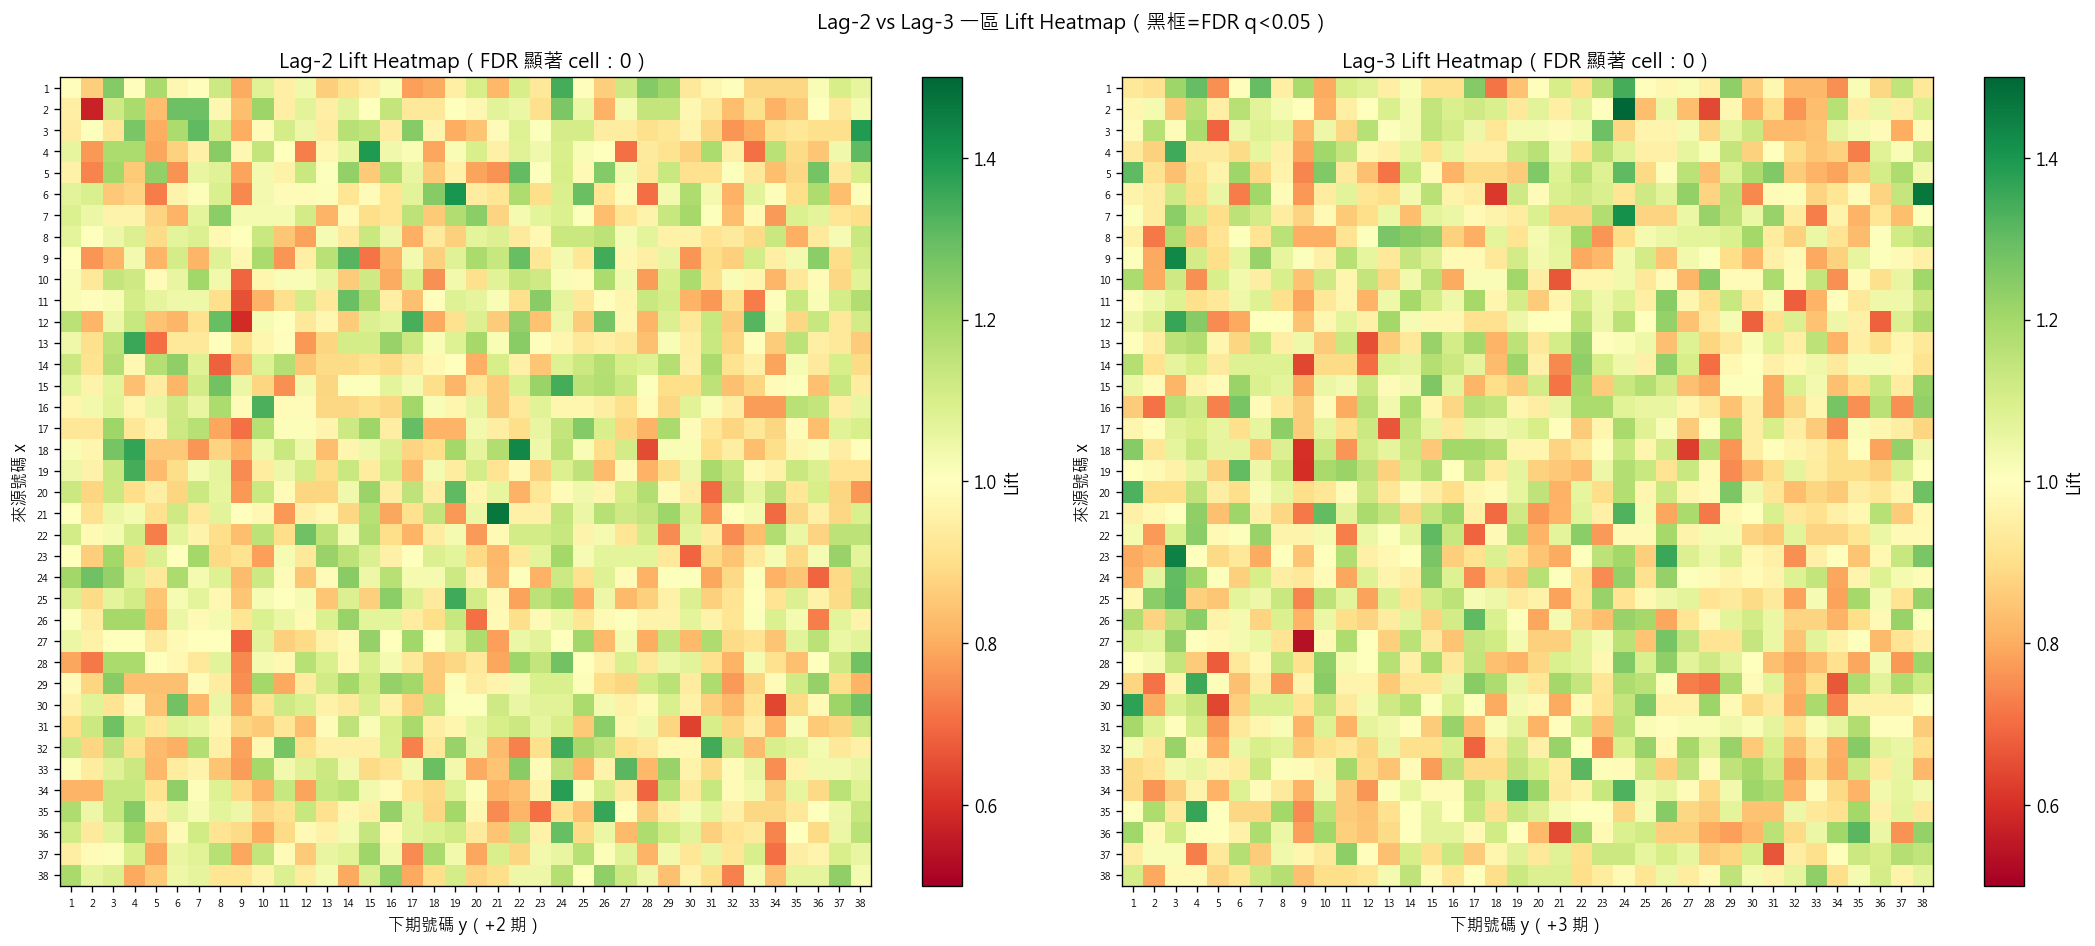

In [5]:
# Lift heatmap 並列（一區，lag 2 & 3）
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, lag in zip(axes, [2, 3]):
    r   = results[lag]
    T   = r["T_z1"]
    fsrc = r["freq_z1"]
    tA   = r["z1"]["testA_df"]

    lift_mat = np.full((38, 38), np.nan)
    for _, row in tA.iterrows():
        lift_mat[int(row.x)-1, int(row.y)-1] = row.lift

    im = ax.imshow(lift_mat, cmap="RdYlGn", vmin=0.5, vmax=1.5, aspect="auto")
    plt.colorbar(im, ax=ax, label="Lift")

    sig = r["z1"]["sig_A"]
    if len(sig) > 0:
        for _, row in sig.iterrows():
            ax.add_patch(plt.Rectangle(
                (row.y-1.5, row.x-1.5), 1, 1,
                fill=False, edgecolor="black", linewidth=1.5
            ))

    ax.set_xticks(range(38)); ax.set_xticklabels(range(1,39), fontsize=6)
    ax.set_yticks(range(38)); ax.set_yticklabels(range(1,39), fontsize=6)
    ax.set_xlabel("下期號碼 y（+{} 期）".format(lag))
    ax.set_ylabel("來源號碼 x")
    n_sig = len(sig)
    ax.set_title(f"Lag-{lag} Lift Heatmap（FDR 顯著 cell：{n_sig}）")

plt.suptitle("Lag-2 vs Lag-3 一區 Lift Heatmap（黑框=FDR q<0.05）", fontsize=12)
plt.tight_layout()
plt.show()

## 4. 最小 p-value 追蹤 & 家族誤差率評估

三個 lag 加起來共做了 3 × 1,444 = 4,332 個 Test A 檢定。  
若不跨 lag 校正，即使每個 lag 內部 FDR 控制在 5%，三個 lag 搜尋下找到訊號的機率會提高。  
這裡做一次**跨 lag 合併 FDR**，看是否有任何 cell 在全局校正後仍顯著。

In [6]:
all_A_rows = []
for lag in [1, 2, 3]:
    r = all_lag_z1[lag] if lag == 1 else results[lag]["z1"]
    for _, row in r["testA_df"].iterrows():
        all_A_rows.append({
            "lag": lag, "x": row.x, "y": row.y,
            "k": row.k, "n": row.n,
            "obs_rate": row.obs_rate, "lift": row.lift,
            "p_raw": row.p_raw,
        })

combined_df = pd.DataFrame(all_A_rows)
_, q_global, _, _ = multipletests(combined_df["p_raw"].values, method="fdr_bh")
combined_df["q_global"] = q_global

sig_global = combined_df[combined_df["q_global"] < 0.05]
print(f"跨 lag 合併 FDR（共 {len(combined_df)} 個檢定）")
print(f"全局 FDR q<0.05：{len(sig_global)} 個")
print()

# 各 lag 最小 p 前 5
print("各 lag 最小原始 p-value top-5（未校正，僅供參考）：")
for lag in [1, 2, 3]:
    sub = combined_df[combined_df["lag"] == lag].nsmallest(5, "p_raw")
    print(f"\nLag-{lag}:")
    print(sub[["x","y","k","n","obs_rate","lift","p_raw","q_global"]].round(4).to_string(index=False))

print()
# p-value 最小值的分布趨勢
min_p_by_lag = combined_df.groupby("lag")["p_raw"].min()
print("各 lag 最小 p-value：")
print(min_p_by_lag.round(6))

跨 lag 合併 FDR（共 4332 個檢定）
全局 FDR q<0.05：0 個

各 lag 最小原始 p-value top-5（未校正，僅供參考）：

Lag-1:
   x    y    k     n  obs_rate   lift  p_raw  q_global
14.0  9.0 26.0 298.0    0.0872 0.5526 0.0004    0.6450
 1.0 22.0 68.0 293.0    0.2321 1.4699 0.0010    0.8223
11.0 24.0 64.0 280.0    0.2286 1.4476 0.0018    0.8223
30.0 15.0 63.0 277.0    0.2274 1.4404 0.0022    0.8223
24.0  2.0 33.0 321.0    0.1028 0.6511 0.0057    0.9144

Lag-2:
   x    y    k     n  obs_rate   lift  p_raw  q_global
21.0 21.0 63.0 272.0    0.2316 1.4669 0.0015    0.8223
 2.0  2.0 24.0 266.0    0.0902 0.5714 0.0018    0.8223
12.0  9.0 26.0 279.0    0.0932 0.5902 0.0023    0.8223
18.0 22.0 62.0 274.0    0.2263 1.4331 0.0028    0.9144
 3.0 38.0 69.0 315.0    0.2190 1.3873 0.0041    0.9144

Lag-3:
   x    y    k     n  obs_rate   lift  p_raw  q_global
 2.0 24.0 65.0 266.0    0.2444 1.5476 0.0003    0.6450
27.0  9.0 24.0 284.0    0.0845 0.5352 0.0004    0.6450
 6.0 38.0 67.0 289.0    0.2318 1.4683 0.0012    0.8223
19.0  9.0 28.0 2

## 5. 總結：Lag 1 / 2 / 3 彙整

In [7]:
print("=" * 65)
print("Lag-1 / 2 / 3 Transition 分析彙整（一區 1–38）")
print("=" * 65)
print(f"{'Lag':<6}{'Test B 原始p<0.05':>18}{'FDR q<0.05':>12}{'Test A FDR q<0.05':>20}")
print("-" * 65)

for lag in [1, 2, 3]:
    r = all_lag_z1[lag] if lag == 1 else results[lag]["z1"]
    b_raw = len(r["sig_B_raw"])
    b_fdr = len(r["sig_B_fdr"])
    a_fdr = len(r["sig_A"])
    print(f"Lag-{lag}  {b_raw:>15}/38  {b_fdr:>9}/38  {a_fdr:>16}/1444")

print()
print(f"跨 lag 合併全局 FDR q<0.05：{len(sig_global)} / {len(combined_df)}")
print()

any_signal = any(
    len((all_lag_z1[l] if l==1 else results[l]["z1"])["sig_A"]) > 0
    for l in [1, 2, 3]
) or len(sig_global) > 0

if not any_signal:
    print("🔴 結論：Lag 1 / 2 / 3 均無通過 FDR 校正的跨期關聯訊號。")
    print("   包含跨 lag 合併全局 FDR 也無顯著 cell。")
    print()
    print("   威力彩歷史資料在 lag-1～3 的 transition 維度上")
    print("   表現與完全獨立的隨機過程一致。")
    print()
    print("   → 建議正式結案（Phase 4），誠實記錄負結果。")
else:
    print("🟡 有 FDR 顯著訊號，需評估是否進入 Phase 2 holdout 驗證。")

print()
print("⚠️  Holdout 100 期全程未使用。")

Lag-1 / 2 / 3 Transition 分析彙整（一區 1–38）
Lag      Test B 原始p<0.05  FDR q<0.05   Test A FDR q<0.05
-----------------------------------------------------------------
Lag-1                0/38          0/38                 0/1444
Lag-2                0/38          0/38                 0/1444
Lag-3                0/38          0/38                 0/1444

跨 lag 合併全局 FDR q<0.05：0 / 4332

🔴 結論：Lag 1 / 2 / 3 均無通過 FDR 校正的跨期關聯訊號。
   包含跨 lag 合併全局 FDR 也無顯著 cell。

   威力彩歷史資料在 lag-1～3 的 transition 維度上
   表現與完全獨立的隨機過程一致。

   → 建議正式結案（Phase 4），誠實記錄負結果。

⚠️  Holdout 100 期全程未使用。
